# Normalization (Machine Learning Interview Preparation)
### 1️⃣ What is Normalization?

- Normalization is a feature scaling technique used to transform numerical data into a common scale (usually between 0 and 1) without distorting the relationships between values.

- It helps machine learning algorithms perform better when features have different ranges.

### 2️⃣ Normalization Formula

- The most common normalization method is Min-Max Scaling:

 - X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}


- Where:

   - X = original value
    
   - Xmin = minimum value of feature
    
   - Xmax = maximum value of feature
    
   - Result → value between 0 and 1


### 4️⃣ Why Normalization is Important

- Machine learning algorithms using distance calculations are sensitive to feature scale.


 - d=(x1​−x2​)2+(y1​−y2​)2


### 5️⃣ Algorithms That Need Normalization

- Normalization is important for:

   - KNN
    
   - K-Means Clustering
    
   - SVM
    
   - Neural Networks
    
   - Gradient Descent algorithms

- Because they rely on distance or gradient calculations


### 6️⃣ Algorithms That Do NOT Need Normalization

- Tree-based models are scale-invariant:

  -  Decision Trees
    
  -  Random Forest
    
  -  XGBoost
    
  -  LightGBM

### 7️⃣ Types of Normalization
#### 1️⃣ Min-Max Scaling

- Range: 0–1

- Used when data distribution is not Gaussian.

##### 2️⃣ Mean Normalization

- Formula:

- X_{norm} = \frac{X - \mu}{X_{max} - X_{min}}

- Where μ is mean.


#### 3️⃣ Max Absolute Scaling

- X_{scaled} = \frac{X}{|X_{max}|}

- Used when data contains positive and negative values.



### 🔟 One-Line Interview Answer

Normalization is a feature scaling technique that transforms numerical values into a common range (usually 0–1) to ensure all features contribute equally to machine learning models.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [23]:
# import the data through url of campusx repo of ml nprmalization
import requests
from io import StringIO
import pandas as pd

url = "https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/main/day25-normalization/wine_data.csv"

headers = {"User-Agent": "Mozilla/5.0"}

req = requests.get(url, headers=headers)
data = StringIO(req.text)

df = pd.read_csv(data)

df.head()

,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
0,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450


In [24]:
df.rename(columns={'1':'class label','14.23':'alcohol','1.71':'malic acid'},inplace=True)

In [25]:
df=df[['class label','alcohol','malic acid']]
df

,class label,alcohol,malic acid
0,1,13.20,1.78
1,1,13.16,2.36
2,1,14.37,1.95
3,1,13.24,2.59
4,1,14.20,1.76
...,...,...,...
172,3,13.71,5.65
173,3,13.40,3.91
174,3,13.27,4.28
175,3,13.17,2.59


<Axes: xlabel='alcohol', ylabel='Density'>

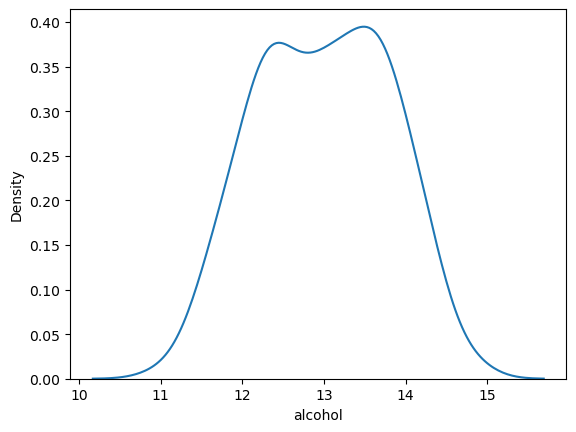

In [27]:
sns.kdeplot(df['alcohol'])

<Axes: xlabel='malic acid', ylabel='Density'>

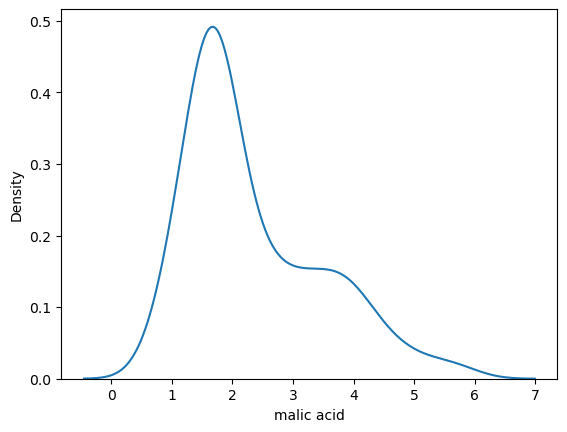

In [28]:
sns.kdeplot(df['malic acid'])

In [59]:
color_dict={1:'red',3:'green',2:'blue'}
sns.scatterplot(df['alcohol'],df['malic acid'],hue=df['class label'],palette=color_dict)
plt.show()

TypeError: scatterplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 2 keyword-only arguments) were given

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('class label', axis=1),
                                                    df['class label'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((123, 2), (54, 2))

In [35]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [36]:
# fit the scaler to the train set ,it will learn the parameters
scaler.fit(X_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [44]:
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [52]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [53]:
X_test_scaled,X_train_scaled

(     alcohol  malic acid
 0   0.680108    0.171079
 1   0.473118    0.362525
 2   0.306452    0.114053
 3   0.857527    0.164969
 4   0.225806    0.696538
 5   0.373656    0.720978
 6   1.021505    0.152749
 7   0.357527    0.598778
 8   0.454301    0.175153
 9   0.260753    0.126273
 10  0.650538    0.572301
 11  0.766129    0.845214
 12  0.903226    0.199593
 13  0.338710    0.464358
 14  0.685484    0.344196
 15  0.454301    0.187373
 16  0.666667    0.185336
 17  0.701613    0.450102
 18  0.709677    0.073320
 19  0.750000    0.175153
 20  0.360215    0.057026
 21  0.548387    0.124236
 22  0.852151    0.177189
 23  0.373656    0.338086
 24  0.432796    0.095723
 25  0.196237    0.364562
 26  0.204301    0.252546
 27  0.166667    0.158859
 28  0.102151   -0.030550
 29  0.739247    0.380855
 30  0.610215    0.169043
 31  0.607527    0.219959
 32  0.491935    0.093686
 33  0.900538    0.549898
 34  0.760753    0.093686
 35  0.854839    0.641548
 36  0.715054    0.482688
 37  0.33871

In [50]:
np.round(X_train.describe(),1)

,alcohol,malic acid
count,123.0,123.0
mean,13.0,2.3
std,0.8,1.2
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.8
75%,13.6,3.1
max,14.8,5.8


In [56]:
np.round(X_train_scaled.describe(),1)

,alcohol,malic acid
count,123.0,123.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.1
50%,0.5,0.2
75%,0.7,0.4
max,1.0,1.0


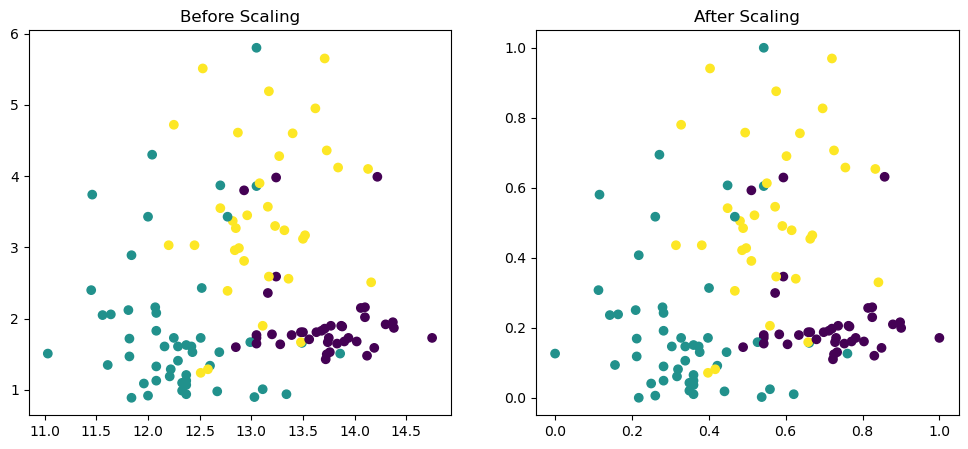

In [58]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['alcohol'], X_train['malic acid'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['alcohol'], X_train_scaled['malic acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

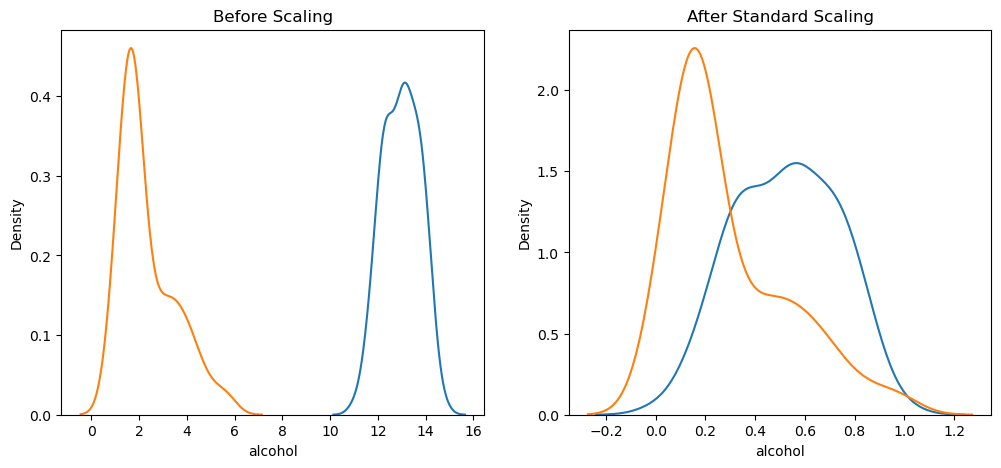

In [60]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['alcohol'], ax=ax1)
sns.kdeplot(X_train['malic acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['malic acid'], ax=ax2)
plt.show()

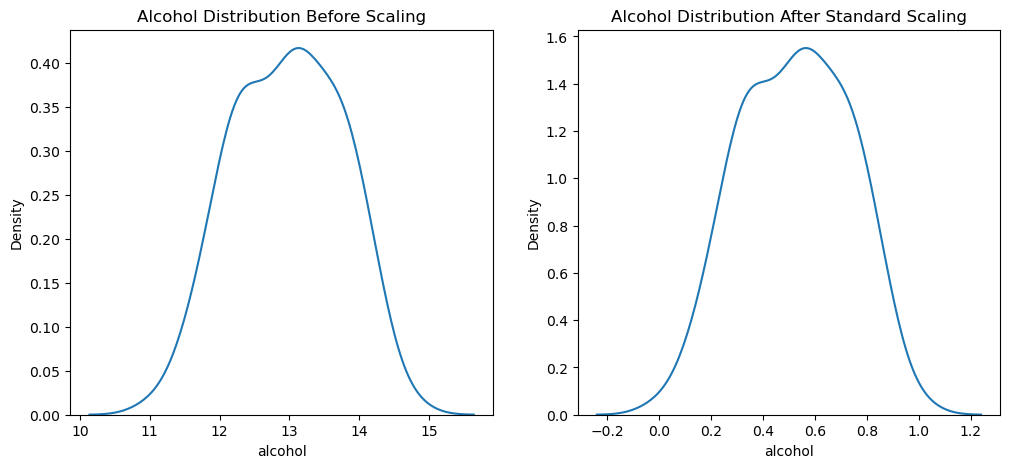

In [61]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['alcohol'], ax=ax2)
plt.show()

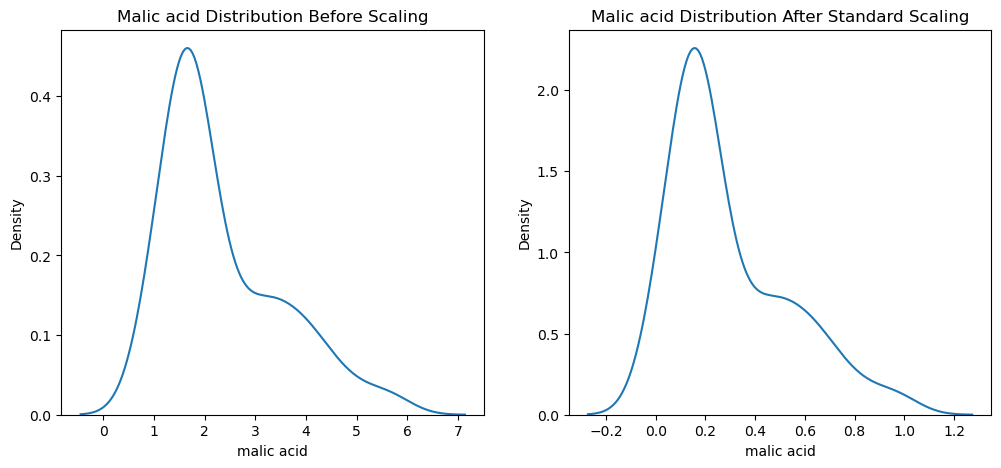

In [62]:

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['malic acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['malic acid'], ax=ax2)
plt.show()